
# Empirical penalty cap from short-term volatility

A winning solver has an exclusivity window to settle an order. If the price moves against it by more than the penalty, reverting is cheaper than settling, so the cap decides how often reverts happen. This notebook sets the cap empirically:

> **cap(order) = k x sigma_1s(pair) x sqrt(T) x order size**

- `sigma_1s`: the pair's per-second volatility, measured with TSRV on tick data (noise-robust).
- `T`: the exclusivity window in seconds; volatility over the window grows with sqrt(T).
- `k`: the multiplier that hits the target revert rate. Read directly from the historical distribution of window price moves (a quantile), not from a parametric distribution.
- Order size: linear, since all quantities are in bps of order size.

**Data.** Binance spot tick data for ETHUSDT, SOLUSDT, DOGEUSDT, BNBUSDT, POLUSDT, AVAXUSDT and USDCUSDT. Training: May 1-30 2026 (volatility and `k`). Testing: June 1-10 2026, held out; May 31 is also loaded to supply the first previous-day vol estimate. On the test days we count, per window, how often the end price falls below the expected band (start price minus the expected vol move)

In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

T_EXCL = 24                        # headline exclusivity window (s), ~2 mainnet blocks
T_GRID = [12, 24, 36]              # 1 / 2 / 3 mainnet blocks
Q_TARGET = 0.05                    # target revert rate

# ---- plotting: static plotly ----
pio.renderers.default = "png"
pio.renderers["png"].scale = 2
C_PAIR = {"ETHUSDT": "#2a78d6", "SOLUSDT": "#1baf7a", "DOGEUSDT": "#eb6834", "BNBUSDT": "#4a3aa7",
          "POLUSDT": "#8247e5", "AVAXUSDT": "#c22f2f", "USDCUSDT": "#c9a227"}
PAIRS = list(C_PAIR)
GRAY, INK, GRID, SURF, AXIS = "#898781", "#0b0b0b", "#e1e0d9", "#fcfcfb", "#c3c2b7"

def style(fig, w=1050, h=430, title=None):
    fig.update_layout(width=w, height=h, template="none", paper_bgcolor=SURF, plot_bgcolor=SURF,
                      font=dict(size=13, color=INK), margin=dict(l=65, r=30, t=60, b=50),
                      legend=dict(bgcolor="rgba(0,0,0,0)"))
    if title: fig.update_layout(title=dict(text=title, font=dict(size=15)))
    fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    return fig
print("params set")

params set


## 1. Data and volatility

- Trades are cleaned (duplicates dropped). 
- Volatility is estimated with TSRV method on 5-minute blocks

In [2]:
import os, zipfile, urllib.request, pandas as pd

CACHE = os.path.expanduser("~/dev/penalty-research/data/binance_ticks")
os.makedirs(CACHE, exist_ok=True)
DAYS_TRAIN = [f"2026-05-{d:02d}" for d in range(1, 31)]    # 30 days
DAYS_TEST = [f"2026-06-{d:02d}" for d in range(1, 11)]     # 10 days, held out
WINDOW_VOL_S = 300

PERP_ONLY = set()          # pairs not listed on Binance spot would fall back to USD-M perp prints

def fetch(symbol, day):
    fn = f"{symbol}-aggTrades-{day}.zip"
    path = os.path.join(CACHE, fn)
    if not os.path.exists(path):
        seg = "futures/um/daily" if symbol in PERP_ONLY else "spot/daily"
        urllib.request.urlretrieve(
            f"https://data.binance.vision/data/{seg}/aggTrades/{symbol}/{fn}", path)
    return path

def load_ticks(symbol, days):
    frames = []
    for d in days:
        with zipfile.ZipFile(fetch(symbol, d)) as z:
            name = z.namelist()[0]
            hh = not z.open(name).read(64)[:1].isdigit()
            cols = ["aggId","price","qty","firstId","lastId","ts","isBuyerMaker","isBestMatch"]
            df = pd.read_csv(z.open(name), header=0 if hh else None, names=None if hh else cols)
            if hh:
                df.columns = [str(c).lower() for c in df.columns]
                tcol = [c for c in df.columns if "time" in c or c == "ts" or "transact" in c][0]
                df = df.rename(columns={tcol: "ts"})
            df = df[["price", "ts"]].astype({"ts": "int64", "price": float})
            unit = "us" if df["ts"].iloc[0] > 10**14 else "ms"
            df["t"] = pd.to_datetime(df["ts"], unit=unit, utc=True)
            frames.append(df[["t", "price"]])
    return pd.concat(frames).sort_values("t").reset_index(drop=True)

def clean(df, k=25, mad_mult=3.0, floor_ticks=2.0, floor_bps=1.0):
    df = df[(df.price > 0) & df.price.notna()].drop_duplicates(subset=["t", "price"]).copy()
    tick = np.median(np.diff(np.unique(np.sort(df.price.values))))
    med = df.price.rolling(2*k + 1, center=True, min_periods=k).median()
    mad = (df.price - med).abs().rolling(2*k + 1, center=True, min_periods=k).median()
    floor_abs = max(floor_ticks*tick, df.price.median()*floor_bps*1e-4)
    keep = ((df.price - med).abs() <= mad_mult*mad + floor_abs).fillna(True)
    return df[keep].set_index("t")

def rv_all(lp):
    r = np.diff(lp); return float(r @ r)

def tsrv(lp, K):
    # two-scale realized variance, finite-sample adjusted
    n = len(lp) - 1
    if n < 2*K + 2: return np.nan
    rva = np.mean([np.sum(np.diff(lp[k::K])**2) for k in range(K)])
    nbar = (n - K + 1)/K
    return max((rva - (nbar/n)*rv_all(lp))/(1 - nbar/n), 0.0)

def prep(symbol, days):
    ticks = clean(load_ticks(symbol, days))
    px = ticks.price.resample("1s").last().ffill()
    return ticks, px

def block_vols(ticks, px):
    # per-5-min-block TSRV vol, per-second units, bps
    n_blocks = int((len(px) - 1)//WINDOW_VOL_S)
    edges = px.index[0] + pd.to_timedelta(np.arange(n_blocks + 1)*WINDOW_VOL_S, unit="s")
    pos = ticks.index.searchsorted(edges)
    lp_all = np.log(ticks.price.values)
    out = np.full(n_blocks, np.nan)
    for b in range(n_blocks):
        lp = lp_all[pos[b]:pos[b + 1]]
        if len(lp) < 200: continue
        Kw = max(2, min(int(round(len(lp)*10.0/WINDOW_VOL_S)), (len(lp) - 2)//2))
        out[b] = np.sqrt(tsrv(lp, Kw)/WINDOW_VOL_S)*1e4
    return out

# everything is computed per day so that vol and k can be re-estimated on a rolling basis
POOL_DAYS = DAYS_TRAIN + ["2026-05-31"] + DAYS_TEST     # May 1 - June 10, in order
DAY_PX, DAY_BLOCKS, SIGMA_1S, SIGMA_1S_PREV = {}, {}, {}, {}
for p in PAIRS:
    DAY_PX[p], DAY_BLOCKS[p] = {}, {}
    for d in POOL_DAYS:
        ticks, px = prep(p, [d])
        DAY_BLOCKS[p][d] = block_vols(ticks, px)
        DAY_PX[p][d] = px
        del ticks
    SIGMA_1S[p] = float(np.nanmedian(np.concatenate([DAY_BLOCKS[p][d] for d in DAYS_TRAIN])))
    SIGMA_1S_PREV[p] = {d: float(np.nanmedian(DAY_BLOCKS[p][prev]))
                        for prev, d in zip(POOL_DAYS[30:-1], DAYS_TEST)}
sigma_T = lambda pair, T: SIGMA_1S[pair]*np.sqrt(T)

print(f"{'pair':10s} {'sigma_1s May':>13s} {'prev-day vol range in June':>27s}   (bps/sqrt(s))")
for p in PAIRS:
    vs = list(SIGMA_1S_PREV[p].values())
    print(f"{p:10s} {SIGMA_1S[p]:13.3f} {min(vs):15.3f} - {max(vs):.3f}")

pair        sigma_1s May  prev-day vol range in June   (bps/sqrt(s))
ETHUSDT            0.362           0.255 - 1.816
SOLUSDT            0.566           0.483 - 2.191
DOGEUSDT           0.796           0.474 - 2.008
BNBUSDT            0.353           0.632 - 1.544
POLUSDT            1.263           1.154 - 2.190
AVAXUSDT           0.969           1.050 - 2.214
USDCUSDT           0.010           0.009 - 0.014


## 2. Window moves and the empirical k

Divide the training sample into non-overlapping windows of `T` seconds. Each window's move is the end price versus the start price, in bps: let's assume this is what a solver faces between winning and the settle deadline.

**Why moves are divided by vol.** `sigma_1s x sqrt(T)` is the typical (one standard deviation) price move for that pair over a `T`-second window: example: ~1.8 bps for ETHUSDT at 24s, ~3.9 bps for DOGEUSDT. Dividing each move by its pair's typical move converts it into "how unusual" is the current move relative to the standard deviation move: a raw -4 bps move is an ordinary window for DOGE (about 1x its typical move) but a bad one for ETH (over 2x). This separates the two components of the cap: the typical size (`sigma`) and the shape of the distribution (how often 1x, 2x, 3x typical moves happen), which is what `k` is.

`k` then comes straight from the data:

> `k = |5% quantile of window moves| / (sigma_1s x sqrt(T))`

i.e. the cap that keeps price-driven reverts to 5% of windows, expressed as a multiple of the pair's window volatility so it transfers across pairs and windows. No distributional assumption; the quantile is read off the sorted moves. The figure shows the move distributions with moves scaled by window vol, so pairs are comparable.

pair        T(s)  vol_T  q10 move      k   (training)
ETHUSDT       12   1.26     -3.43   2.73
ETHUSDT       24   1.77     -4.97   2.80
ETHUSDT       36   2.17     -6.13   2.82
SOLUSDT       12   1.96     -4.28   2.19
SOLUSDT       24   2.77     -5.93   2.14
SOLUSDT       36   3.39     -7.34   2.16
DOGEUSDT      12   2.76     -5.10   1.85
DOGEUSDT      24   3.90     -7.23   1.85
DOGEUSDT      36   4.78     -8.90   1.86
BNBUSDT       12   1.22     -2.90   2.37
BNBUSDT       24   1.73     -4.26   2.46
BNBUSDT       36   2.12     -5.30   2.51
POLUSDT       12   4.37    -10.20   2.33
POLUSDT       24   6.19    -10.52   1.70
POLUSDT       36   7.58    -10.66   1.41
AVAXUSDT      12   3.36    -10.46   3.12
AVAXUSDT      24   4.75    -10.79   2.27
AVAXUSDT      36   5.82    -10.91   1.88
USDCUSDT      12   0.03     -0.10   2.98
USDCUSDT      24   0.05     -0.10   2.11
USDCUSDT      36   0.06     -0.10   1.72


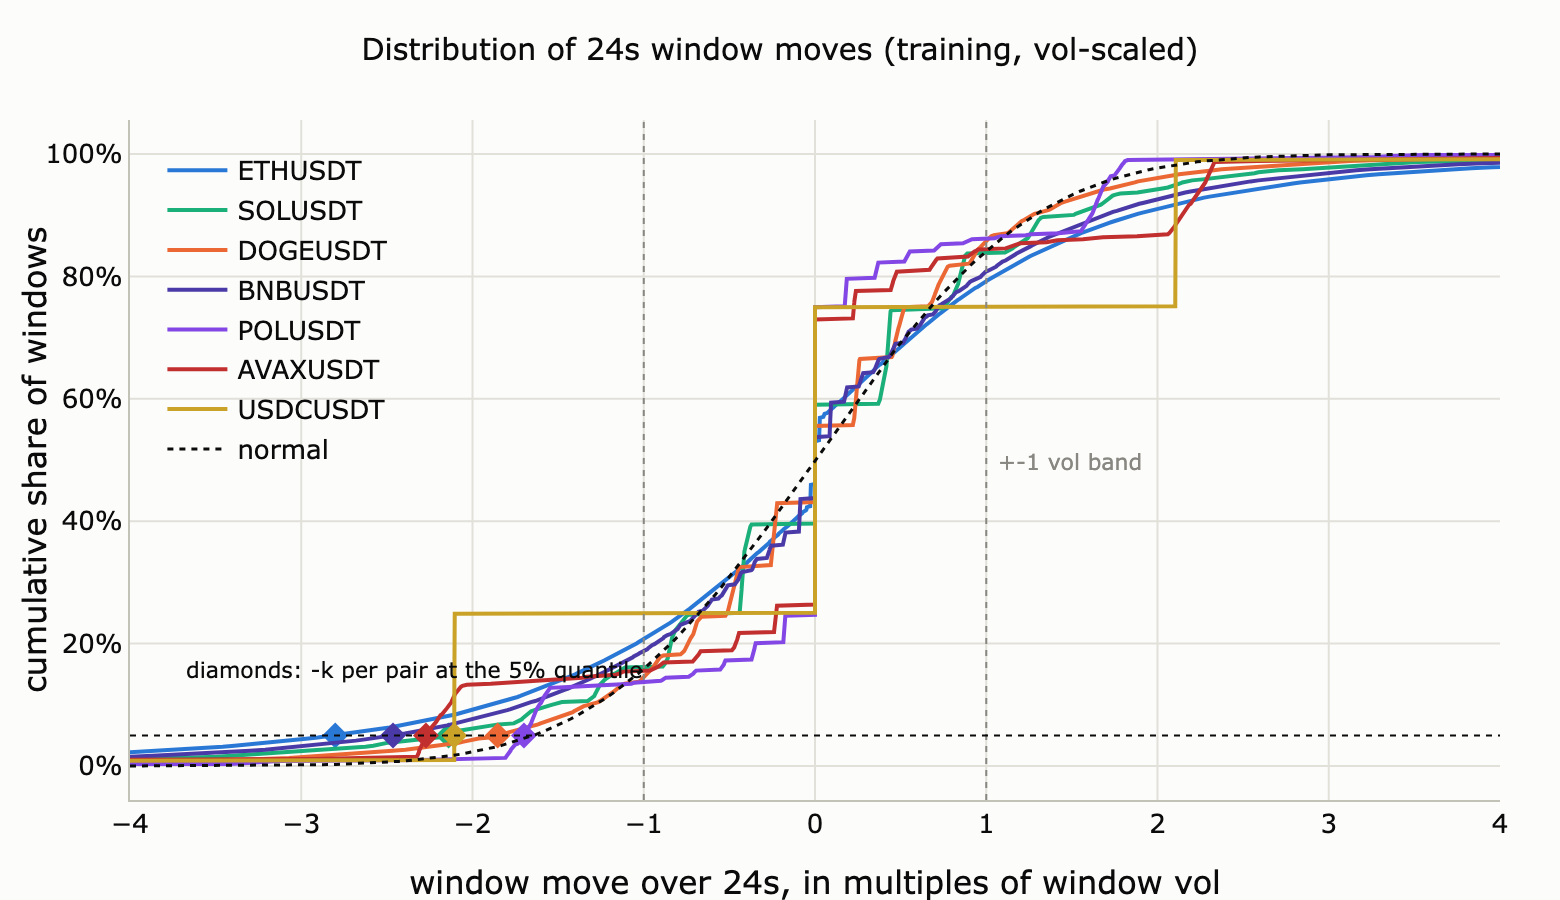

In [3]:
def window_moves(px, T):
    v = px.values
    n = (len(v) - 1)//T
    p0 = v[: n*T: T]
    p1 = v[T: n*T + 1: T]
    return (p1/p0 - 1.0)*1e4     # bps

MV_DAY = {}
def moves_over(pair, days, T):
    # concatenated window moves over a list of days (windows never span a day boundary)
    return np.concatenate([MV_DAY.setdefault((pair, d, T), window_moves(DAY_PX[pair][d], T))
                           for d in days])

K_EMP = {p: {} for p in PAIRS}
print(f"{'pair':10s} {'T(s)':>5s} {'vol_T':>6s} {'q10 move':>9s} {'k':>6s}   (training)")
for p in PAIRS:
    for T in T_GRID:
        mv = moves_over(p, DAYS_TRAIN, T)
        q10 = float(np.quantile(mv, Q_TARGET))
        K_EMP[p][T] = -q10/sigma_T(p, T)
        print(f"{p:10s} {T:5d} {sigma_T(p, T):6.2f} {q10:9.2f} {K_EMP[p][T]:6.2f}")

fig = go.Figure()
for p in PAIRS:
    mv = moves_over(p, DAYS_TRAIN, T_EXCL)/sigma_T(p, T_EXCL)
    xs = np.sort(mv)[:: max(1, len(mv)//600)]
    fig.add_trace(go.Scatter(x=xs, y=np.linspace(0, 1, len(xs)), mode="lines",
                             line=dict(color=C_PAIR[p], width=2), name=p))
    fig.add_trace(go.Scatter(x=[-K_EMP[p][T_EXCL]], y=[Q_TARGET], mode="markers",
                             marker=dict(size=10, color=C_PAIR[p], symbol="diamond"),
                             showlegend=False))
from math import erf
xs_n = np.linspace(-4, 4, 200)
fig.add_trace(go.Scatter(x=xs_n, y=[0.5*(1 + erf(x/1.41421356)) for x in xs_n], mode="lines",
                         line=dict(color=INK, dash="dot", width=1.5), name="normal"))
for x in (-1, 1):
    fig.add_vline(x=x, line=dict(color=GRAY, dash="dot", width=1))
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1))
fig.add_annotation(text="+-1 vol band", x=1.05, y=0.5, xanchor="left", showarrow=False,
                   font=dict(color=GRAY, size=11))
fig.add_annotation(text=f"diamonds: -k per pair at the {Q_TARGET:.0%} quantile", x=-3.7, y=0.16,
                   xanchor="left", showarrow=False, font=dict(size=11))
fig.update_xaxes(title=f"window move over {T_EXCL}s, in multiples of window vol", range=[-4, 4])
fig.update_yaxes(title="cumulative share of windows", tickformat=".0%")
style(fig, w=780, h=450, title=f"Distribution of {T_EXCL}s window moves (training, vol-scaled)")
fig.update_layout(legend=dict(x=0.02, y=0.97))
fig.show()

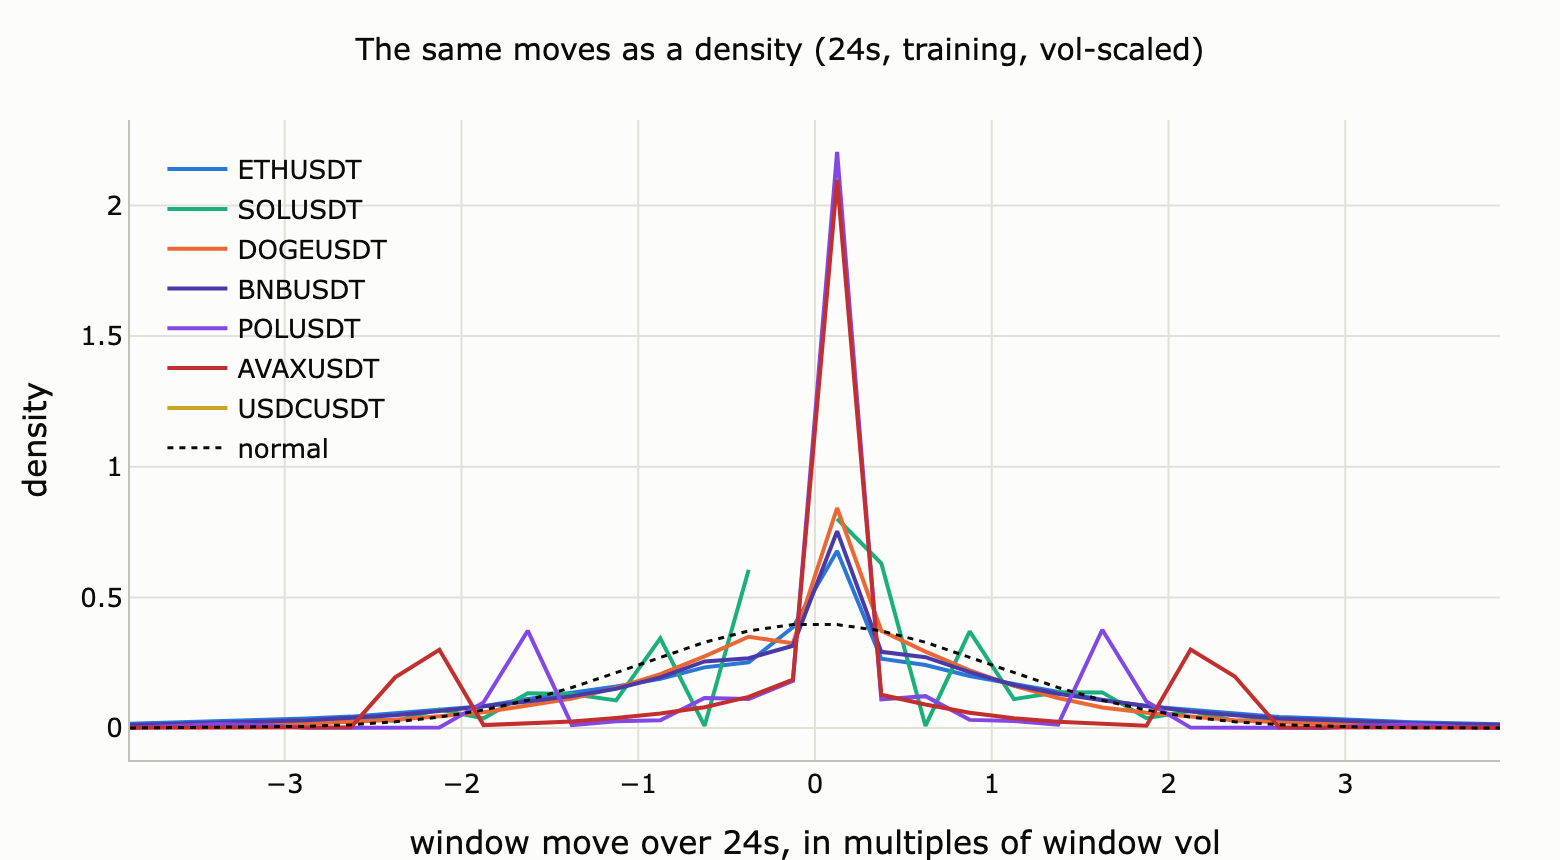

In [4]:
bins = np.linspace(-4, 4, 33)
centers = (bins[:-1] + bins[1:])/2
fig = go.Figure()
for p in PAIRS:
    mv = moves_over(p, DAYS_TRAIN, T_EXCL)/sigma_T(p, T_EXCL)
    h, _ = np.histogram(mv, bins=bins, density=True)
    fig.add_trace(go.Scatter(x=centers, y=np.where(h > 0, h, np.nan), mode="lines",
                             line=dict(color=C_PAIR[p], width=2), name=p))
pdf = np.exp(-centers**2/2)/np.sqrt(2*np.pi)
fig.add_trace(go.Scatter(x=centers, y=pdf, mode="lines",
                         line=dict(color=INK, dash="dot", width=1.5), name="normal"))
fig.update_xaxes(title=f"window move over {T_EXCL}s, in multiples of window vol")
fig.update_yaxes(title="density")
style(fig, w=780, h=430, title=f"The same moves as a density ({T_EXCL}s, training, vol-scaled)")
fig.update_layout(legend=dict(x=0.02, y=0.97))
fig.show()

- In the cumulative chart, each curve is one pair's distribution of window moves in the training month: the price change from window start to end, divided by that pair's expected vol move (`sigma_1s x sqrt(T)`), so all pairs share one x-axis. A point reads: "y% of windows (y-axis) ended with a move below this many vols (x-axis)". The marker indicate where each curve crosses 5%: that x-position is the pair's `-k`, the cap in vol units breached in exactly 5% of training windows. The dotted curve is a normal distribution, which crosses 5% at -1.64

- The density chart shows the same moves as a distribution. It makes the shape difference visible.
- Why the quiet majors have the fattest scaled tails: DOGE delivers its variance in a steady churn, so a typical window already looks like an average one; ETH and BNB are calm most of the time and deliver a large share of their variance in bursts, so their bad windows sit far beyond a typical one. And since `sigma_1s` is the MEDIAN 5-minute block, `k` also prices how clustered a pair's volatility is relative to its everyday level, not just tail fatness.
    - Practical consequence: ETH needs its cap furthest out in vol multiples (k ~ 2.8) to hit the same 5% breach rate, yet its cap in bps stays among the smallest because its vol level is the lowest (at 24s: ETH 5.0 vs DOGE 7.2 bps).

- A caveat on the smaller pairs. POL and AVAX trade with a large minimum price increment relative to their volatility: one tick is several bps, versus <1 bp for the majors. Roughly half of their 24s windows show zero move and the rest land on whole-tick multiples (i.e. noise  or bounce); that is the tall spike at zero and the isolated bumps in their densities, and the staircase in their cumulative curves. USDC/USDT is the extreme case: its 5% quantile move is exactly one tick (0.1 bp) at every window, so the cap floors at one tick and its k is just that tick divided by window vol.

## 3. Out of sample test (June 1-10)

1. **How often did prices drop more than one expected vol move?** For each window, check whether the end price finishes below the start minus one expected move (`sigma_1s x sqrt(T)`, calibrated in May). The bars compare the share of such windows in May itself with the share in June, against the same May band. June bars far above May bars mean the market simply moved more than the calibration month. (Upside volatilit as well is found but not shown here, soJune brought bigger moves in both directions, not a drift.)
2. **Did the cap hold?** A revert happens when the end price falls below the start by more than the cap. Three versions of the cap, from most stale to most adaptive, all walk-forward (each day's cap is built only from data available before that day, so no look-forward bias):
   - **May k x May vol**: parameters frozen at the end of May.
   - **May k x latest 24h vol**: the multiplier stays fixed; `sigma_1s` is re-estimated each test day from the previous day's ticks, so the June 4 cap uses June 3 volatility.
   - **Rolling 30-day k x latest 24h vol**: `k` is also re-read every day, as the 5% quantile of vol-scaled window moves over the trailing 30 days, paired with the latest 24h vol.
   - **Direct percentile, 24h and 7d lookbacks**: the simpler alternative. Slice the recent past into `T`-second windows, rank the moves, and read the cap straight off the target percentile. No `k`, no volatility estimate, no `sqrt(T)`; one number per day per pair. Two lookbacks are tested: the previous day only (direct 24h) and the trailing 7 days (direct 7d). On the same sample this is algebraically identical to `k x vol` (that is how `k` is defined), so the comparison tests how much data the percentile needs to be stable (~3,600 windows per day at 24s) against how quickly it adapts when the vol level moves.

pair        T(s)       n  below -1 May  below -1 June  Mayk x Mayvol  Mayk x 24h  rollk x 24h  direct 24h  direct 7d   (test June 1-10)
ETHUSDT       12  71,990         18.4%          34.4%          17.8%        4.5%         4.3%        7.0%       9.3%
ETHUSDT       24  35,990         20.8%          35.8%          17.9%        4.4%         4.2%        7.0%       9.5%
ETHUSDT       36  23,990         21.5%          36.1%          18.5%        4.6%         4.3%        7.2%       9.3%
SOLUSDT       12  71,989         17.5%          29.4%          18.0%        5.2%         5.1%        7.3%       9.4%
SOLUSDT       24  35,990         16.1%          33.3%          19.1%        5.4%         5.0%        7.3%       9.4%
SOLUSDT       36  23,990         18.4%          32.0%          19.1%        5.6%         4.9%        6.9%       9.7%
DOGEUSDT      12  71,989         14.3%          22.5%          10.8%        6.2%         5.9%        6.9%       8.3%
DOGEUSDT      24  35,990         14.5%       

BNBUSDT       12  71,990         16.6%          32.6%          18.2%        3.6%         3.0%        5.3%       7.1%
BNBUSDT       24  35,990         18.7%          34.6%          18.7%        3.4%         2.9%        5.1%       6.9%
BNBUSDT       36  23,990         19.9%          35.4%          19.0%        3.4%         2.8%        5.2%       7.2%
POLUSDT       12  71,989          9.9%          11.4%           2.6%        1.4%         2.5%        6.4%       8.1%
POLUSDT       24  35,990         13.7%          13.7%           5.6%        3.2%         4.8%        6.5%       8.6%
POLUSDT       36  23,990         15.9%          14.1%           8.3%        5.2%         7.1%        6.6%       8.7%
AVAXUSDT      12  71,989         11.6%          21.1%           3.8%        1.1%         2.1%        7.4%       9.6%
AVAXUSDT      24  35,990         15.6%          22.6%           8.1%        3.0%         5.2%        7.1%       9.4%
AVAXUSDT      36  23,990         17.6%          24.9%          1

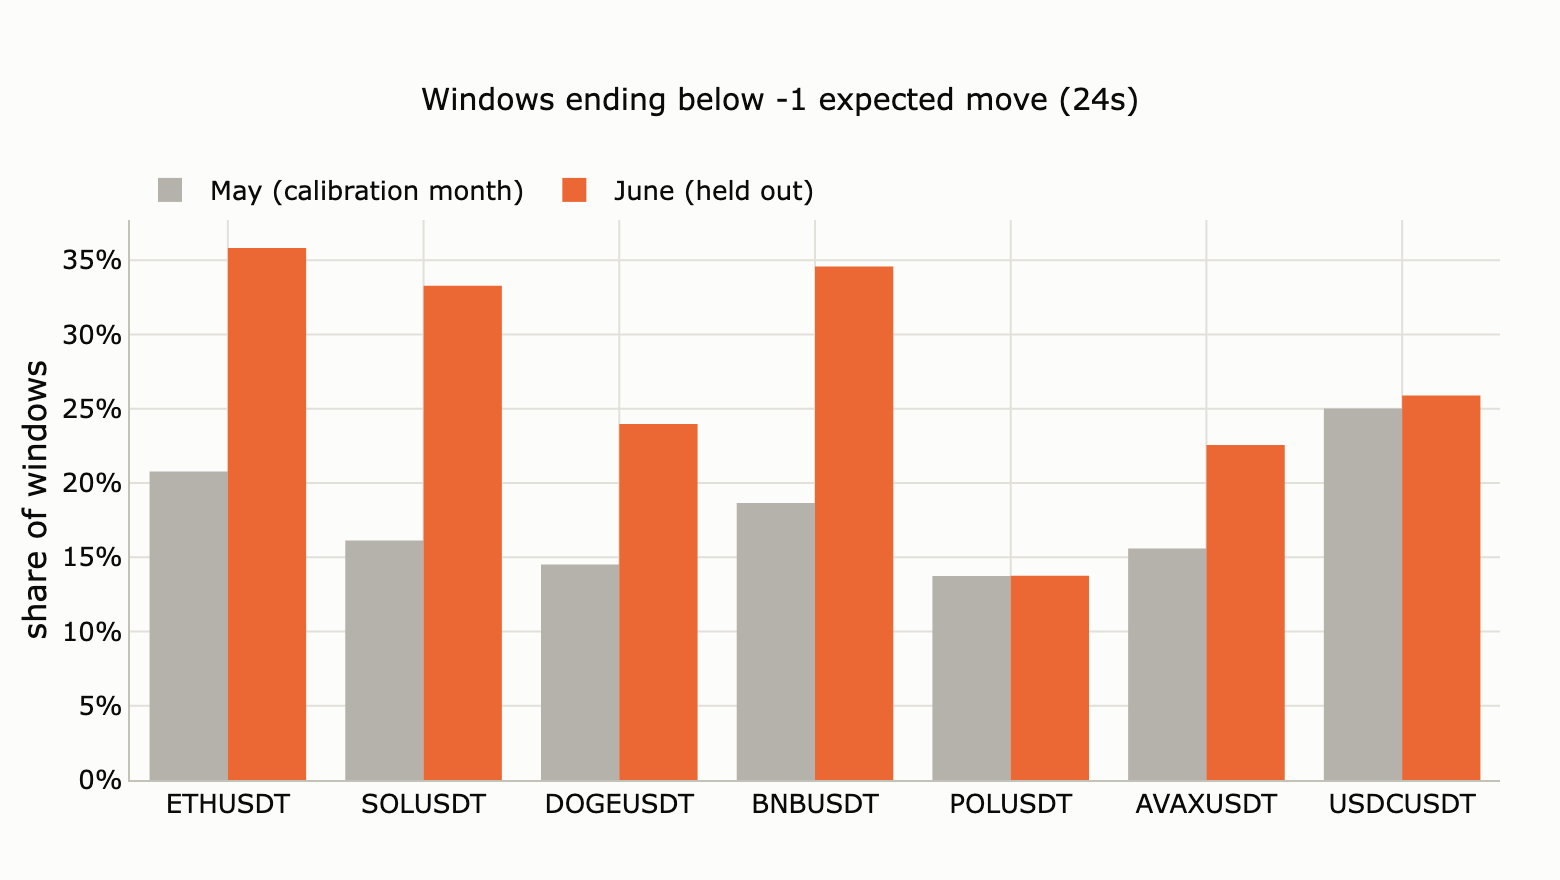

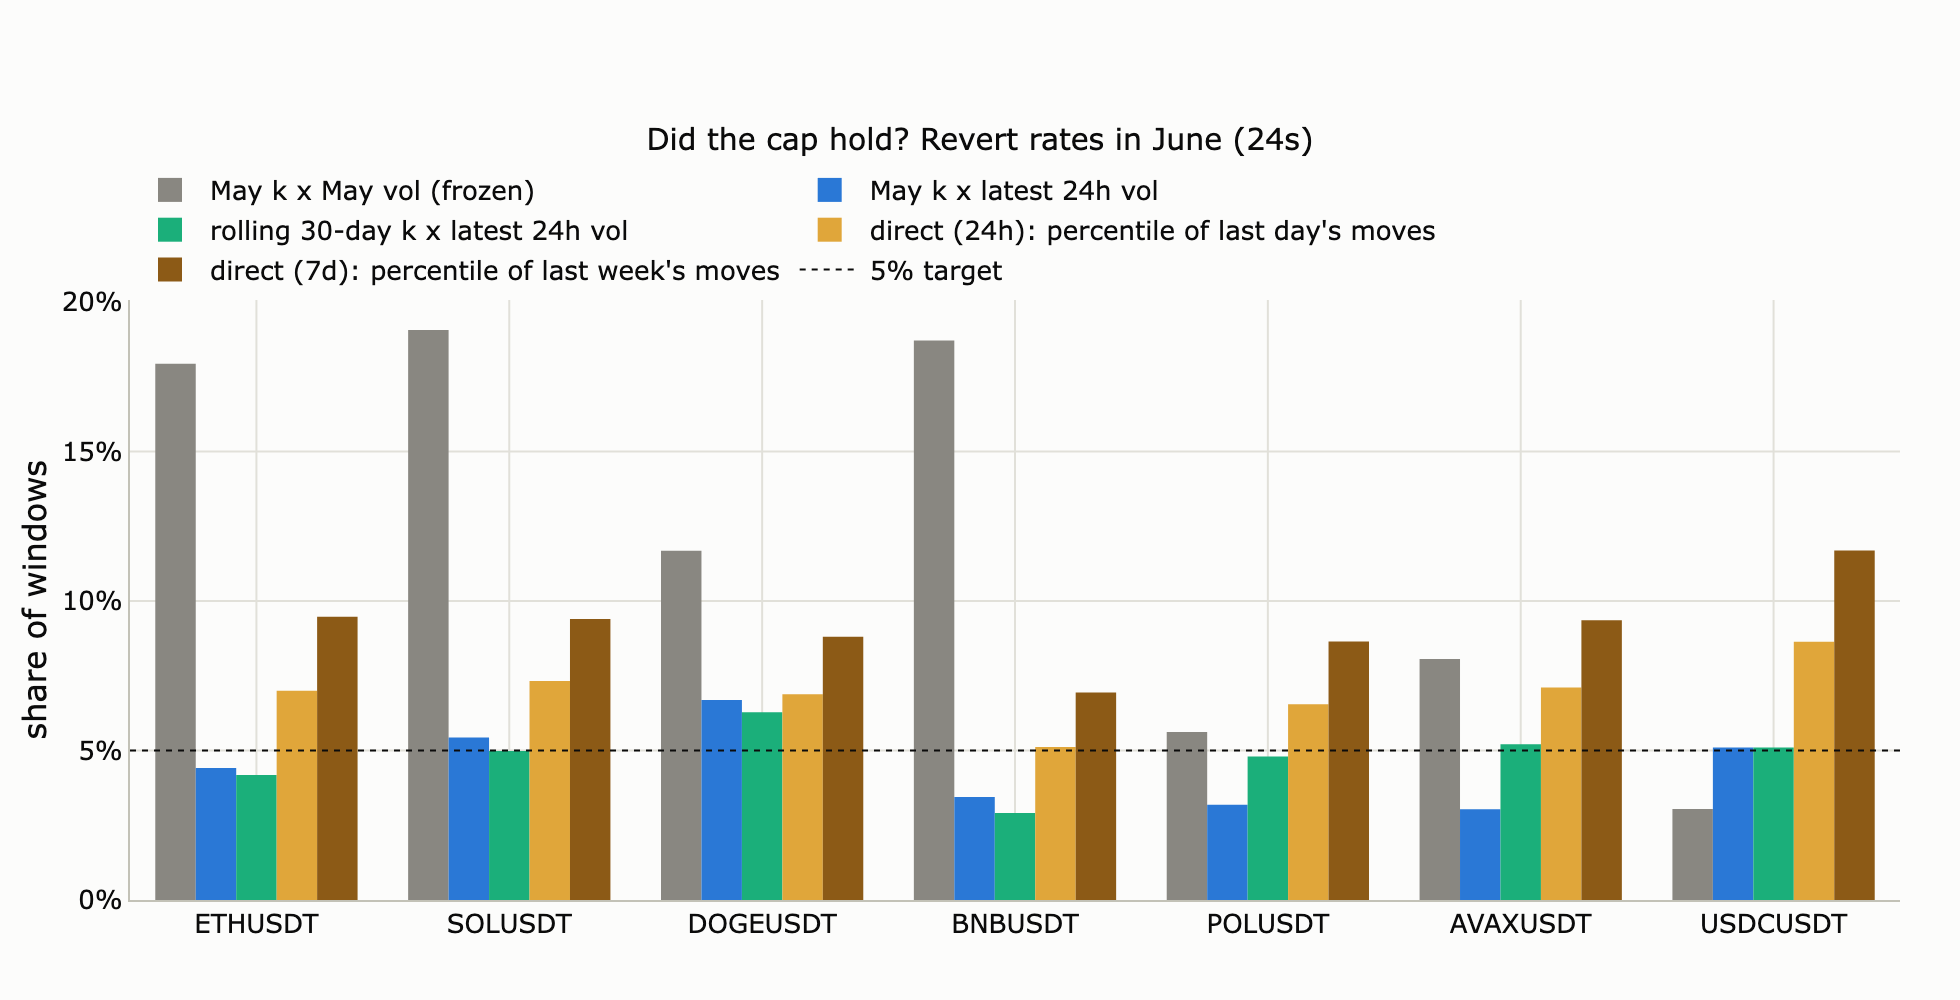

In [5]:
TEST, K_ROLL = {p: {} for p in PAIRS}, {p: {} for p in PAIRS}
DIR_CAP, DIR7_CAP, ROLL_CAP = {p: {} for p in PAIRS}, {p: {} for p in PAIRS}, {p: {} for p in PAIRS}
print(f"{'pair':10s} {'T(s)':>5s} {'n':>7s} {'below -1 May':>13s} {'below -1 June':>14s} "
      f"{'Mayk x Mayvol':>14s} {'Mayk x 24h':>11s} {'rollk x 24h':>12s} {'direct 24h':>11s} {'direct 7d':>10s}   (test June 1-10)")
for p in PAIRS:
    for T in T_GRID:
        sT_tr = sigma_T(p, T)
        below_tr = float(np.mean(moves_over(p, DAYS_TRAIN, T) < -sT_tr))
        below_te, rev_may, rev_daily, rev_roll, rev_dir, rev_dir7, ks, dcaps, d7caps, rcaps = [], [], [], [], [], [], [], [], [], []
        for d in DAYS_TEST:
            i = POOL_DAYS.index(d)
            trail = POOL_DAYS[i - 30: i]                       # latest 30 days before d
            mv30 = moves_over(p, trail, T)
            sig30 = float(np.nanmedian(np.concatenate([DAY_BLOCKS[p][dd] for dd in trail])))
            k_r = -float(np.quantile(mv30, Q_TARGET))/(sig30*np.sqrt(T))
            ks.append(k_r)
            # direct method: rank past T-window moves, cap = the target percentile (24h and 7d lookbacks)
            cap_dir = -float(np.quantile(moves_over(p, [POOL_DAYS[i - 1]], T), Q_TARGET))
            cap_dir7 = -float(np.quantile(moves_over(p, POOL_DAYS[i - 7: i], T), Q_TARGET))
            dcaps.append(cap_dir)
            d7caps.append(cap_dir7)
            mv = moves_over(p, [d], T)
            sT_prev = SIGMA_1S_PREV[p][d]*np.sqrt(T)
            below_te.append(mv < -sT_tr)
            rev_may.append(mv < -K_EMP[p][T]*sT_tr)
            rev_daily.append(mv < -K_EMP[p][T]*sT_prev)
            rev_roll.append(mv < -k_r*sT_prev)
            rev_dir.append(mv < -cap_dir)
            rev_dir7.append(mv < -cap_dir7)
            rcaps.append(k_r*sT_prev)
        K_ROLL[p][T] = (min(ks), max(ks))
        DIR_CAP[p][T] = float(np.mean(dcaps))
        DIR7_CAP[p][T] = float(np.mean(d7caps))
        ROLL_CAP[p][T] = float(np.mean(rcaps))
        below = float(np.mean(np.concatenate(below_te)))
        r_may = float(np.mean(np.concatenate(rev_may)))
        r_daily = float(np.mean(np.concatenate(rev_daily)))
        r_roll = float(np.mean(np.concatenate(rev_roll)))
        r_dir = float(np.mean(np.concatenate(rev_dir)))
        r_dir7 = float(np.mean(np.concatenate(rev_dir7)))
        n = sum(len(a) for a in below_te)
        TEST[p][T] = (below_tr, below, r_may, r_daily, r_roll, r_dir, r_dir7, n)
        print(f"{p:10s} {T:5d} {n:7,} {below_tr:13.1%} {below:14.1%} "
              f"{r_may:14.1%} {r_daily:11.1%} {r_roll:12.1%} {r_dir:11.1%} {r_dir7:10.1%}")
print()
print("below -1: share of windows ending below start minus one expected move (May band).")
print("Mayk x Mayvol = frozen | Mayk x 24h = May k, previous-day vol | "
      "rollk x 24h = trailing-30-day k, previous-day vol | "
      "direct (24h) = target percentile of the previous day's window moves, no k / vol / sqrt(T) | "
      "direct (7d) = same, over the trailing 7 days.")
print()
print(f"rolling k range across the June days, {T_EXCL}s window (May k for reference):")
for p in PAIRS:
    print(f"  {p:10s} {K_ROLL[p][T_EXCL][0]:.2f} - {K_ROLL[p][T_EXCL][1]:.2f}   (May: {K_EMP[p][T_EXCL]:.2f})")

fig = go.Figure()
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][0] for p in PAIRS],
                     name="May (calibration month)", marker_color="#b5b2ab"))
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][1] for p in PAIRS],
                     name="June (held out)", marker_color="#eb6834"))
fig.update_yaxes(title="share of windows", tickformat=".0%")
style(fig, w=780, h=440, title=f"Windows ending below -1 expected move ({T_EXCL}s)")
fig.update_layout(barmode="group", margin=dict(t=110),
                  legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0.0))
fig.show()

fig = go.Figure()
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][2] for p in PAIRS],
                     name="May k x May vol (frozen)", marker_color="#898781"))
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][3] for p in PAIRS],
                     name="May k x latest 24h vol", marker_color="#2a78d6"))
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][4] for p in PAIRS],
                     name="rolling 30-day k x latest 24h vol", marker_color="#1baf7a"))
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][5] for p in PAIRS],
                     name="direct (24h): percentile of last day's moves", marker_color="#e0a63a"))
fig.add_trace(go.Bar(x=PAIRS, y=[TEST[p][T_EXCL][6] for p in PAIRS],
                     name="direct (7d): percentile of last week's moves", marker_color="#8c5a16"))
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1))
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
                         line=dict(color=INK, dash="dot", width=1), name=f"{Q_TARGET:.0%} target"))
fig.update_yaxes(title="share of windows", tickformat=".0%")
style(fig, w=980, h=500, title=f"Did the cap hold? Revert rates in June ({T_EXCL}s)")
fig.update_layout(barmode="group", margin=dict(t=150),
                  legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0.0))
fig.show()

## 4. The cap table

Evaluating `cap = k x sigma_1s x sqrt(T) x order size` with the May inputs, in bps of order size. For incorporating order size, we just multiply by notional.

`roll cap`, `dir 24h cap` and `dir 7d cap` are directly comparable: all are June averages of the daily walk-forward caps. `roll cap` uses the rolling 30-day `k` times the latest 24h vol; the direct caps read the cap straight off the target percentile of past window moves (no `k`, no vol), over the previous day and the trailing 7 days respectively. Their June revert rates are in the last columns.

## 5. Steps for setting the Penalty cap

1. **Measure volatility.** TSRV per-second vol per pair on recent tick data; refresh on a rolling window.
2. **Take the window from config.** `T` = the chain's exclusivity window in seconds; vol over the window = `sigma_1s x sqrt(T)`.
3. **Pick the revert-rate target.** ex: 5%
4. **Read `k` from the data.** The 5% quantile of historical window moves divided by window vol. No distributional assumption. One thing to think about here is whether to calculate 1 average k for similar assets (when data is sparse).
5. **Compute the cap:** `cap(order) = k x sigma_1s x sqrt(T) x order size`.

In [6]:
print(f"cap = k x sigma_1s x sqrt(T) x size (bps of order size; k empirical at the {Q_TARGET:.0%} target)")
print(f"{'pair':10s} {'T(s)':>5s} {'vol_T':>6s} {'k':>5s} {'roll cap':>9s} {'dir 24h cap':>12s} {'dir 7d cap':>11s} "
      f"{'test: frozen':>13s} {'Mayk x 24h':>11s} {'rollk x 24h':>12s} {'direct 24h':>11s} {'direct 7d':>10s}")
for p in PAIRS:
    for T in T_GRID:
        print(f"{p:10s} {T:5d} {sigma_T(p, T):6.2f} {K_EMP[p][T]:5.2f} "
              f"{ROLL_CAP[p][T]:9.2f} {DIR_CAP[p][T]:12.2f} {DIR7_CAP[p][T]:11.2f} {TEST[p][T][2]:13.1%} "
              f"{TEST[p][T][3]:11.1%} {TEST[p][T][4]:12.1%} {TEST[p][T][5]:11.1%} {TEST[p][T][6]:10.1%}")
print("roll cap    = June average of the daily walk-forward caps, rolling 30-day k x latest 24h vol (bps)")
print("dir 24h cap = June average of the daily walk-forward caps, percentile of the previous day (bps)")
print("dir 7d cap  = same, percentile of the trailing 7 days (bps)")
print("vol_T and k are the May calibration values, shown for reference.")
print()
print("current fixed USD caps, converted to bps of order size (USD cap / order notional):")
print(f"{'chain':10s} {'USD cap':>8s} {'$1k order':>10s} {'$5k order':>10s} "
      f"{'$10k order':>11s} {'$100k order':>12s} {'$1M order':>10s}")
for usd, name in [(21.15, "ethereum"), (24.72, "bnb"), (2.62, "polygon")]:
    print(f"{name:10s} {usd:8.2f} {usd/1_000*1e4:6.0f} bps {usd/5_000*1e4:6.1f} bps "
          f"{usd/10_000*1e4:7.1f} bps {usd/100_000*1e4:8.2f} bps {usd/1_000_000*1e4:6.3f} bps")

cap = k x sigma_1s x sqrt(T) x size (bps of order size; k empirical at the 5% target)
pair        T(s)  vol_T     k  roll cap  dir 24h cap  dir 7d cap  test: frozen  Mayk x 24h  rollk x 24h  direct 24h  direct 7d
ETHUSDT       12   1.26  2.73      9.86         7.06        6.05         17.8%        4.5%         4.3%        7.0%       9.3%
ETHUSDT       24   1.77  2.80     14.26        10.16        8.71         17.9%        4.4%         4.2%        7.0%       9.5%
ETHUSDT       36   2.17  2.82     17.64        12.57       10.81         18.5%        4.6%         4.3%        7.2%       9.3%
SOLUSDT       12   1.96  2.19      9.87         8.12        7.10         18.0%        5.2%         5.1%        7.3%       9.4%
SOLUSDT       24   2.77  2.14     14.00        11.84       10.27         19.1%        5.4%         5.0%        7.3%       9.4%
SOLUSDT       36   3.39  2.16     17.39        14.88       12.75         19.1%        5.6%         4.9%        6.9%       9.7%
DOGEUSDT      12   2.76  